## **Objective:**

The objective of this task is to build a Natural Language Processing (NLP) model capable of identifying and
classifying sentiments expressed in textual data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [3]:
df = pd.read_csv(r'/content/IMDB Dataset.csv')

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (50000, 2)


In [5]:
print(df.columns)

Index(['review', 'sentiment'], dtype='object')


In [6]:
df.isnull().sum()

,0
review,0
sentiment,0


In [7]:
print("Number of duplicate reviews:", df.duplicated(subset="review").sum())

Number of duplicate reviews: 418


In [8]:
df = df.drop_duplicates(subset="review")
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (49582, 2)


In [9]:
print(df["sentiment"].value_counts())

sentiment
positive    24884
negative    24698
Name: count, dtype: int64


In [10]:
df["sentiment"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

## **Text Preprocessing**
1. Lowercasing
2. HTML removal
3. URL removal
4. Punctuation/noise removal
5. Tokenization
6. Stopword removal
7. Lemmatization

In [11]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [12]:
def preprocess_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Keep only alphabetic characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Tokenization
    words = text.split()

    # Remove stopwords and perform lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words back into a sentence
    return " ".join(words)

In [13]:
sample_review = df["review"].iloc[0]

print("Original Review:")
print(sample_review)

print("\nPreprocessed Review:")
print(preprocess_text(sample_review))

Original Review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

In [14]:
df["clean_review"] = df["review"].apply(preprocess_text)

In [15]:
df[["review", "clean_review", "sentiment"]].head()

,review,clean_review,sentiment
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...,1
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,1
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,1
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...,1


In [16]:
print("Empty cleaned reviews:", (df["clean_review"].str.strip() == "").sum())

Empty cleaned reviews: 0


In [17]:
print("Final dataset shape:", df.shape)

Final dataset shape: (49582, 3)


## **Feature Extraction using TF-IDF Vectorizer**

In [18]:
X = df["clean_review"]
y = df["sentiment"]

In [19]:
print("Number of reviews:", len(X))
print("Number of labels:", len(y))

Number of reviews: 49582
Number of labels: 49582


In [20]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [21]:
print("Training reviews:", len(X_train_text))
print("Testing reviews:", len(X_test_text))

Training reviews: 39665
Testing reviews: 9917


In [22]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

In [23]:
X_train_tfidf = tfidf.fit_transform(X_train_text)

In [24]:
X_test_tfidf = tfidf.transform(X_test_text)

In [25]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (39665, 10000)
Testing TF-IDF shape: (9917, 10000)


In [26]:
feature_names = tfidf.get_feature_names_out()

print("Number of features:", len(feature_names))

print("\nFirst 30 features:")
print(feature_names[:30])

Number of features: 10000

First 30 features:
['aaron' 'abandon' 'abandoned' 'abbott' 'abc' 'ability' 'able' 'able get'
 'able make' 'able see' 'aboard' 'abomination' 'abortion' 'abound'
 'abraham' 'abroad' 'abrupt' 'abruptly' 'absence' 'absent' 'absolute'
 'absolutely' 'absolutely loved' 'absolutely nothing' 'absorbed'
 'absorbing' 'abstract' 'absurd' 'absurdity' 'abuse']


In [27]:
X_train_tfidf_df = pd.DataFrame(X_train_tfidf.toarray(), columns=feature_names)
X_test_tfidf_df = pd.DataFrame(X_test_tfidf.toarray(), columns=feature_names)

In [28]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [29]:
logistic_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [30]:
logistic_predictions = logistic_model.predict(X_test_tfidf)

In [31]:
print(logistic_predictions[:20])

[0 1 1 0 0 1 0 0 1 0 0 1 1 0 1 0 1 0 1 0]


In [32]:
nb_model = MultinomialNB()

In [33]:
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [34]:
nb_predictions = nb_model.predict(X_test_tfidf)

In [35]:
print(nb_predictions[:20])

[0 1 1 0 0 1 0 0 1 0 0 1 1 0 1 0 1 0 1 0]


In [36]:
logistic_accuracy = accuracy_score(y_test, logistic_predictions)

logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions
)

In [37]:
print("Logistic Regression Results")
print("--------------------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1-Score :", round(logistic_f1, 4))

Logistic Regression Results
--------------------------------
Accuracy : 0.8948
Precision: 0.8854
Recall   : 0.908
F1-Score : 0.8965


In [38]:
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      4940
    Positive       0.89      0.91      0.90      4977

    accuracy                           0.89      9917
   macro avg       0.90      0.89      0.89      9917
weighted avg       0.90      0.89      0.89      9917



In [39]:
logistic_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

print(logistic_cm)

[[4355  585]
 [ 458 4519]]


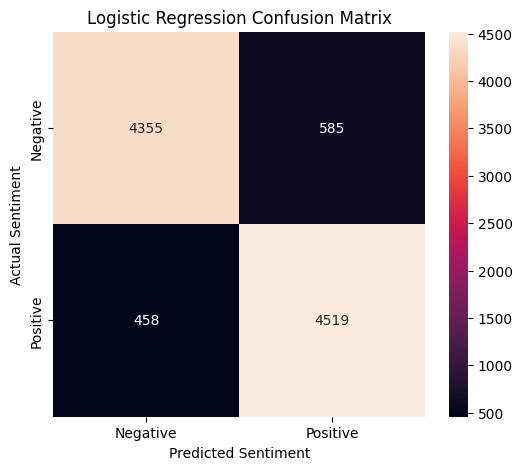

In [40]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

In [41]:
nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

nb_precision = precision_score(
    y_test,
    nb_predictions
)

nb_recall = recall_score(
    y_test,
    nb_predictions
)

nb_f1 = f1_score(
    y_test,
    nb_predictions
)

In [42]:
print("Naive Bayes Results")
print("--------------------------------")
print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1-Score :", round(nb_f1, 4))

Naive Bayes Results
--------------------------------
Accuracy : 0.8691
Precision: 0.8603
Recall   : 0.8825
F1-Score : 0.8713


In [43]:
print(
    classification_report(
        y_test,
        nb_predictions,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87      4940
    Positive       0.86      0.88      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



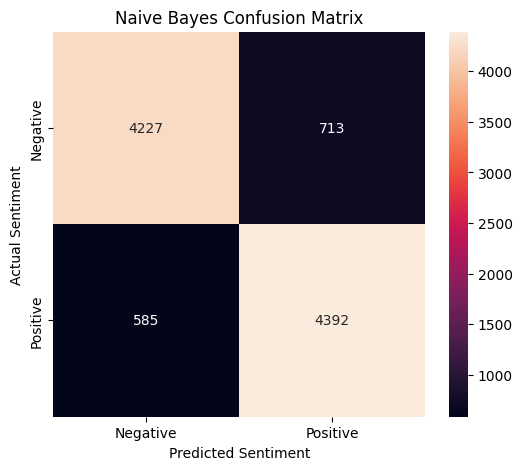

In [44]:
nb_cm = confusion_matrix(
    y_test,
    nb_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

In [45]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes"
    ],
    "Accuracy": [
        logistic_accuracy,
        nb_accuracy
    ],
    "Precision": [
        logistic_precision,
        nb_precision
    ],
    "Recall": [
        logistic_recall,
        nb_recall
    ],
    "F1-Score": [
        logistic_f1,
        nb_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.894827,0.885384,0.907977,0.896538
1,Naive Bayes,0.869114,0.860333,0.882459,0.871256


In [46]:
best_model = results.loc[
    results["F1-Score"].idxmax()
]

print("Best Model:", best_model["Model"])
print("F1-Score:", best_model["F1-Score"])

Best Model: Logistic Regression
F1-Score: 0.8965380418609264


In [47]:
best_accuracy_model = results.loc[
    results["Accuracy"].idxmax()
]

print("Best model based on Accuracy:", best_accuracy_model["Model"])

Best model based on Accuracy: Logistic Regression


In [48]:
new_reviews = [
    "This movie was absolutely amazing and I loved every minute of it.",
    "The movie was terrible, boring and a complete waste of time.",
    "The acting was excellent and the story was very enjoyable.",
    "I hated this movie. It was poorly written and extremely disappointing."
]

In [49]:
new_reviews_clean = [
    preprocess_text(review)
    for review in new_reviews
]

In [50]:
new_reviews_tfidf = tfidf.transform(new_reviews_clean)

In [51]:
new_predictions = logistic_model.predict(
    new_reviews_tfidf
)

In [52]:
for review, prediction in zip(new_reviews, new_predictions):

    sentiment = "Positive" if prediction == 1 else "Negative"

    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
    print("-" * 80)

Review: This movie was absolutely amazing and I loved every minute of it.
Predicted Sentiment: Positive
--------------------------------------------------------------------------------
Review: The movie was terrible, boring and a complete waste of time.
Predicted Sentiment: Negative
--------------------------------------------------------------------------------
Review: The acting was excellent and the story was very enjoyable.
Predicted Sentiment: Positive
--------------------------------------------------------------------------------
Review: I hated this movie. It was poorly written and extremely disappointing.
Predicted Sentiment: Negative
--------------------------------------------------------------------------------


In [53]:
new_probabilities = logistic_model.predict_proba(
    new_reviews_tfidf
)

for review, prediction, probability in zip(
    new_reviews,
    new_predictions,
    new_probabilities
):

    sentiment = "Positive" if prediction == 1 else "Negative"

    confidence = max(probability) * 100

    print("Review:", review)
    print("Prediction:", sentiment)
    print("Confidence:", round(confidence, 2), "%")
    print("-" * 80)

Review: This movie was absolutely amazing and I loved every minute of it.
Prediction: Positive
Confidence: 87.7 %
--------------------------------------------------------------------------------
Review: The movie was terrible, boring and a complete waste of time.
Prediction: Negative
Confidence: 99.97 %
--------------------------------------------------------------------------------
Review: The acting was excellent and the story was very enjoyable.
Prediction: Positive
Confidence: 99.64 %
--------------------------------------------------------------------------------
Review: I hated this movie. It was poorly written and extremely disappointing.
Prediction: Negative
Confidence: 99.42 %
--------------------------------------------------------------------------------


In [54]:
feature_names = tfidf.get_feature_names_out()

coefficients = logistic_model.coef_[0]

positive_indices = coefficients.argsort()[-20:]

positive_words = feature_names[positive_indices]

positive_scores = coefficients[positive_indices]

positive_features = pd.DataFrame({
    "Feature": positive_words,
    "Coefficient": positive_scores
}).sort_values(
    "Coefficient",
    ascending=False
).reset_index(drop=True)

positive_features

,Feature,Coefficient
0,great,7.140585
1,excellent,6.649132
2,perfect,5.494141
3,amazing,5.121828
4,wonderful,4.892539
5,best,4.563529
6,brilliant,4.424955
7,one best,4.322736
8,favorite,4.314194
9,loved,4.311928


In [55]:
print("FINAL MODEL SUMMARY")
print("=" * 50)

print("Dataset: IMDb Movie Reviews")
print("Feature Extraction: TF-IDF")
print("Primary Model: Logistic Regression")

print("\nEvaluation Results:")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1-Score :", round(logistic_f1, 4))

FINAL MODEL SUMMARY
Dataset: IMDb Movie Reviews
Feature Extraction: TF-IDF
Primary Model: Logistic Regression

Evaluation Results:
Accuracy : 0.8948
Precision: 0.8854
Recall   : 0.908
F1-Score : 0.8965
